In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [5]:
PROJECT_ROOT = Path.cwd().parent
train_path = PROJECT_ROOT / "all_datasets" / "titanic_dataset" / "Titanic-Dataset.csv"
df = pd.read_csv(train_path)

In [6]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
X = df[features]
y = df["Survived"]
num_cols = ["Age", "SibSp", "Parch", "Fare"]
cat_cols = ["Pclass", "Sex", "Embarked"]

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])
model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000)),
])

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
model.fit(X_train, y_train)
prob = model.predict_proba(X_valid)[:, 1]
print("Validation ROC AUC:", round(roc_auc_score(y_valid, prob), 3))

Validation ROC AUC: 0.842


In [7]:
for threshold in [0.30, 0.50, 0.70]:
    pred = (prob >= threshold).astype(int)
    print(
        threshold,
        "precision=", round(precision_score(y_valid, pred, zero_division=0), 3),
        "recall=", round(recall_score(y_valid, pred, zero_division=0), 3),
    )

thresholds = np.linspace(0.10, 0.90, 17)
precisions, recalls = [], []
for threshold in thresholds:
    pred = (prob >= threshold).astype(int)
    precisions.append(precision_score(y_valid, pred, zero_division=0))
    recalls.append(recall_score(y_valid, pred))

0.3 precision= 0.636 recall= 0.814
0.5 precision= 0.725 recall= 0.674
0.7 precision= 0.896 recall= 0.5


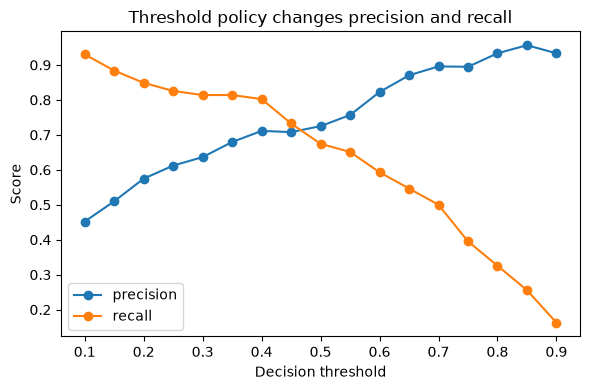

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(thresholds, precisions, marker="o", label="precision")
plt.plot(thresholds, recalls, marker="o", label="recall")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Threshold policy changes precision and recall")
plt.legend()
plt.tight_layout()
plt.show()